# AKIKO ORUI_ Log Regression and XG Boost

In [97]:
import warnings
warnings.filterwarnings('ignore')

import sys
import os

# 💡 Path to your working folder (where models.py and data_utils.py are)
PROJECT_DIR = '/Users/koko/Documents/SINGAPORE/NTU/TERM 1/ML in Finance/PROJECT/MH-6805-Team-Project-/Akiko_Log_XG Boost'

# Add the folder so Python can find your custom modules
if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

# Change current working directory to your project folder
os.chdir(PROJECT_DIR)

print(" Working directory:", os.getcwd())
print(" Python paths include:", PROJECT_DIR in sys.path)


# Now, the imports should work!
import pandas as pd
import numpy as np
import quantstats as qs
import data_utils  
import models      
from tqdm import tqdm
import matplotlib.pyplot as plt
import xgboost
from xgboost import XGBClassifier

# The rest of your setup (like %matplotlib inline, etc.)
%matplotlib inline 
%load_ext autoreload
%autoreload 2

 Working directory: /Users/koko/Documents/SINGAPORE/NTU/TERM 1/ML in Finance/PROJECT/MH-6805-Team-Project-/Akiko_Log_XG Boost
 Python paths include: True
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [98]:
# Project settings
SECTORS_OF_INTEREST = [
    "Information Technology", "Financials", "Consumer Discretionary",
    "Communication Services", "Health Care", "Industrials",
    "Consumer Staples", "Energy", "Materials", "Real Estate", "Utilities"
]
DATA_FILEPATH = 'data/processed/indicators_daily.csv'
BENCHMARK = 'SPY' # S&P 500 ETF as the benchmark

# Backtest settings
TRAIN_WINDOW_DAYS = 365    # 1 year of training data
REBALANCE_FREQ_DAYS = 30 # Rebalance every 30 days
PREDICTION_HORIZON = 30  # Must match the target variable

In [ ]:
def run_rolling_backtest(model_instance, X, y, info_df):
    """
    Runs the core rolling-window backtest logic.
    (rest of the function code...)
    """
    all_dates = pd.DatetimeIndex(sorted(X.index.unique()))

    # Determine the date to start our first prediction
    start_date = all_dates[0] + pd.DateOffset(days=TRAIN_WINDOW_DAYS)

    # Create the list of dates we will rebalance on
    rebalance_dates = pd.date_range(
        start=start_date, 
        end=all_dates[-1], 
        freq=f'{REBALANCE_FREQ_DAYS}D'
    ).normalize()

    all_predictions = []

    print(f"Running backtest for {model_instance.model.__class__.__name__}...")
    # Use tqdm for a progress bar
    for rebal_date in tqdm(rebalance_dates):
        try:
            # Ensure rebal_date is not before the first date in all_dates
            if rebal_date < all_dates[0]:
                continue
            # Find the closest *actual trading day* at or before the rebalance date
            test_date = all_dates.asof(rebal_date)
            if pd.isna(test_date):
                continue
        except Exception as e:
            print(f"Skipping {rebal_date}: {e}")
            continue

        train_end = test_date - pd.DateOffset(days=1)
        train_start = test_date - pd.DateOffset(days=TRAIN_WINDOW_DAYS)
        train_mask = (X.index >= train_start) & (X.index <= train_end)
        X_train, y_train = X[train_mask], y[train_mask]

        test_mask = (X.index == test_date)
        X_test, y_test = X[test_mask], y[test_mask]
        info_test = info_df[test_mask]

        if X_train.empty or X_test.empty:
            continue

        model_instance.fit(X_train, y_train)
        probs = model_instance.predict_proba(X_test)[:, 1]

        results_df = info_test.copy()
        results_df['Date'] = test_date
        results_df['Prob_Up'] = probs
        results_df['Target'] = y_test.values

        all_predictions.append(results_df)

    return pd.concat(all_predictions)


def get_portfolio_allocations(predictions_df):
    """
    Generates sector allocations based on model predictions.
    (rest of the function code...)
    """
    all_allocations = {}

    # Ensure Date is only a column, not also an index
    predictions_df = predictions_df.reset_index(drop=True)
    
    for rebal_date, day_preds in predictions_df.reset_index(drop=True).groupby('Date'):

        top_20_stocks = day_preds.groupby('Sector') \
                               .apply(lambda x: x.nlargest(20, 'Prob_Up')) \
                               .reset_index(drop=True)

        sector_strength = top_20_stocks.groupby('Sector')['Prob_Up'].mean()
        positive_sectors = sector_strength[sector_strength > 0.5]

        if positive_sectors.empty:
            allocations = pd.Series(0.0, index=SECTORS_OF_INTEREST)
        else:
            allocations = positive_sectors / positive_sectors.sum()

        final_allocs = allocations.reindex(SECTORS_OF_INTEREST, fill_value=0.0)
        all_allocations[rebal_date] = final_allocs

    return pd.DataFrame.from_dict(all_allocations, orient='index')


def evaluate_strategy(allocations_df, sector_fwd_returns, benchmark, output_filename, model_name):
    """
    Calculates portfolio returns and generates a quantstats tearsheet.
    (rest of the function code...)
    """
    print(f"Evaluating strategy for {model_name}...")

    allocs, returns = allocations_df.align(sector_fwd_returns, join='inner', axis=0)
    portfolio_returns = (allocs * returns).sum(axis=1)
    portfolio_returns_ts = portfolio_returns.asfreq('D').fillna(0)
    portfolio_returns_ts.name = "Strategy"

    qs.reports.html(
        portfolio_returns_ts,
        benchmark=benchmark,
        output=output_filename,
        title=f'{model_name} Strategy '
    )
    print(f"Report saved to {output_filename}")

In [100]:
DATA_FILEPATH = '/Users/koko/Documents/SINGAPORE/NTU/TERM 1/ML in Finance/PROJECT/MH-6805-Team-Project-/data/processed/indicators_daily.csv'

print("Step 1: Loading and preparing data...")
raw_df = data_utils.load_and_preprocess_data(DATA_FILEPATH)

X, y, info_df, full_df = data_utils.create_target_and_features(
    raw_df, 
    horizon=PREDICTION_HORIZON
)

sector_fwd_returns = data_utils.get_sector_forward_returns(full_df)

print("Data loading complete.")

Step 1: Loading and preparing data...
Data loaded. Shape: (164697, 21)
Engineering target variable for 30-day horizon...
Features and target created. X shape: (164599, 14), y shape: (164599,)
Data loading complete.


In [101]:
# See features
print("Features (X):")
display(X.head())

# See target
print("\nTarget (y):")
display(y.head())
print("\nTarget distribution:")
print(y.value_counts(normalize=True))

# See sector forward returns
print("\nSector Forward Returns:")
display(sector_fwd_returns.head())

Features (X):


,Return,LogReturn,SMA_20,SMA_50,EMA_12,EMA_26,RSI_14,MACD,MACD_Signal,MACD_Hist,BB_Mid,BB_Upper,BB_Lower,ATR_14
Date,,,,,,,,,,,,,,
2022-10-03 04:00:00,0.030753,0.030289,152.0870,159.5014,148.333763,152.723120,36.011739,-4.389357,-3.125437,-1.263920,152.0870,163.495892,140.678108,4.920780
2022-10-03 04:00:00,0.024149,0.023862,86.2710,89.8634,83.861602,86.257948,38.149857,-2.396347,-1.952951,-0.443395,86.2710,93.977678,78.564322,2.084824
2022-10-03 04:00:00,0.065863,0.063785,891.5425,906.3836,861.213501,878.809742,50.406326,-17.596241,-12.147712,-5.448529,891.5425,1011.684095,771.400905,48.291116
2022-10-03 04:00:00,0.021595,0.021365,148.1040,159.5948,141.727952,148.983313,38.055861,-7.255361,-6.719537,-0.535824,148.1040,169.870195,126.337805,5.875324
2022-10-03 04:00:00,0.013971,0.013875,333.0000,345.7808,325.945768,333.265428,44.158336,-7.319660,-6.759169,-0.560491,333.0000,359.474604,306.525396,9.964404



Target (y):


Date
2022-10-03 04:00:00    1
2022-10-03 04:00:00    1
2022-10-03 04:00:00    1
2022-10-03 04:00:00    0
2022-10-03 04:00:00    1
Name: Target, dtype: int64


Target distribution:
Target
1    0.563989
0    0.436011
Name: proportion, dtype: float64

Sector Forward Returns:


Sector,Communication Services,Consumer Discretionary,Consumer Staples,Energy,Financials,Healthcare,Industrials,Materials,Real Estate,Technology,Utilities
Date,,,,,,,,,,,
2022-10-03 04:00:00,0.000510,0.052147,0.088216,0.122205,0.141903,0.102836,0.165610,0.150969,0.033860,0.145415,0.017275
2022-10-04 04:00:00,-0.010323,0.039056,0.072533,0.095341,0.099023,0.078060,0.134786,0.113919,0.026843,0.120604,-0.003354
2022-10-05 04:00:00,-0.015269,0.029075,0.078982,0.075167,0.104395,0.074449,0.136096,0.114137,0.032350,0.090233,0.023670
2022-10-06 04:00:00,-0.018232,0.023806,0.097678,0.078041,0.117151,0.090570,0.149191,0.110373,0.057203,0.094734,0.035783
2022-10-07 04:00:00,0.004365,0.052287,0.121833,0.073860,0.147961,0.120443,0.175671,0.148037,0.093467,0.149859,0.080257


***
KOKO COMMENTS

 - **FEATURES X**: This table shows the input variables (indicators like RSI_14, MACD, SMA_20, etc.) used to predict the target. Each row is a specific stock's data on a specific date.
 **TARGET Y**: This is the binary variable the model is trying to predict. A value of 1 means the stock price will be higher 30 days in the future (a positive return). A value of 0 means the price will be lower or the same.

 - **Target Distribution**: This is crucial for understanding class balance: 56.39% of the historical training examples resulted in an "Up" target (1), and 43.61% resulted in a "Down" target (0). The model is slightly biased towards predicting "Up," which is normal for a long-term equity dataset.

 - **Sector Forward Returns**: This table shows the actual 30-day return for each sector starting on that date. This is the truth used to evaluate the portfolio's performance after a prediction is made.

 - **Feature | Coefficient | Interpretation**

 BB_Upper | Highly Positive (≈0.5) | "A high BB_Upper value strongly increases the probability of the stock going up in the next 30 days. In a scaled model, this is the most powerful positive predictor."

 ATR_14 | Positive (≈0.5)| "High Average True Range (ATR), which measures volatility, strongly increases the probability of an upward move. The model likely sees high volatility as a sign of potential upward momentum."

 SMA_50 | Highly Negative (≈−2.0) | "The Simple Moving Average 50 has the strongest negative impact. A high SMA_50 value strongly decreases the probability of a future upward move. In the context of other variables, the model might be penalizing stocks that are already far above their long-term average."

 LogReturn | Negative (≈−0.1) | A large negative coefficient on LogReturn suggests that a stock with a high recent daily return is slightly less likely to have a positive return 30 days later (a form of mean-reversion).

 ***

# LOGISTIC REGRESSION

In [86]:
print("\nStep 2: Running Logistic Regression Model...")
logreg_model = models.LogRegModel()
logreg_preds = run_rolling_backtest(logreg_model, X, y, info_df)

logreg_allocs = get_portfolio_allocations(logreg_preds)

evaluate_strategy(
    logreg_allocs, 
    sector_fwd_returns, 
    BENCHMARK,
    'Logistic_Regression_Report.html',
    'Logistic Regression'
)
print("Logistic Regression finished.")




Step 2: Running Logistic Regression Model...
Running backtest for LogisticRegression...


100%|██████████| 25/25 [00:14<00:00,  1.78it/s]


Evaluating strategy for Logistic Regression...
Report saved to Logistic_Regression_Report.html
Logistic Regression finished.


***
 **SEE Logistic_Regression_Report.html FILE**

- This table shows the model's predictions for a single day (e.g., 2023-10-02).
- This is the model's predicted probability that the stock will be up in 30 days. For example, RCL has a $59.45\%$ chance (0.594557).
- Target shows how the portfolio was weighted after the model made its prediction, based on your rule (invest in sectors where the top 20 stocks had an average Prob_Up > 0.5).
- The percentage of the total portfolio allocated to that sector for the next 30 days. This is the weight or "W"
- A value of 0.0 means the model decided to not invest in that sector for the next 30 days. This happens if the sector did not meet the "strength" criteria: (Rule: Only invest in sectors where the average "Probability Up" (Prob_Up) of the top 20 predicted stocks is greater than $0.5$ (i.e., the model is more bullish than bearish on the sector's best stocks).)
- High allocation: The allocation values (like $0.092154$) are high because they are normalized weights. Since the sum of all weights must equal $1.0$ (or $100\%$ of the portfolio), the weights are distributed among only the sectors that passed the $0.5$ bullish filter.
***

## ANALYSIS OF LOG REG

Logistic Regression Predictions (sample):
                    Ticker                  Sector                Date  \
Date                                                                     
2023-10-02 04:00:00    RCL  Consumer Discretionary 2023-10-02 04:00:00   
2023-10-02 04:00:00     TT             Industrials 2023-10-02 04:00:00   
2023-10-02 04:00:00    NGG               Utilities 2023-10-02 04:00:00   
2023-10-02 04:00:00    AMX  Communication Services 2023-10-02 04:00:00   
2023-10-02 04:00:00     SO               Utilities 2023-10-02 04:00:00   
2023-10-02 04:00:00      E                  Energy 2023-10-02 04:00:00   
2023-10-02 04:00:00   TTWO  Communication Services 2023-10-02 04:00:00   
2023-10-02 04:00:00    LOW  Consumer Discretionary 2023-10-02 04:00:00   
2023-10-02 04:00:00    MLM               Materials 2023-10-02 04:00:00   
2023-10-02 04:00:00    NKE  Consumer Discretionary 2023-10-02 04:00:00   

                      Prob_Up  Target  
Date                         

,Information Technology,Financials,Consumer Discretionary,Communication Services,Health Care,Industrials,Consumer Staples,Energy,Materials,Real Estate,Utilities
2023-10-02 04:00:00,0.0,0.088983,0.090617,0.088653,0.0,0.090273,0.091131,0.084018,0.092086,0.095608,0.095522
2023-11-01 04:00:00,0.0,0.092154,0.098674,0.092359,0.0,0.088922,0.085056,0.089222,0.089056,0.093023,0.083229
2023-12-01 05:00:00,0.0,0.000000,0.201703,0.198255,0.0,0.000000,0.000000,0.203102,0.000000,0.000000,0.193040
2023-12-29 05:00:00,0.0,0.000000,0.104378,0.102788,0.0,0.096528,0.099542,0.100744,0.097660,0.096245,0.100087
2024-01-30 05:00:00,0.0,0.087396,0.095839,0.091384,0.0,0.090919,0.087445,0.088832,0.089911,0.092160,0.091160


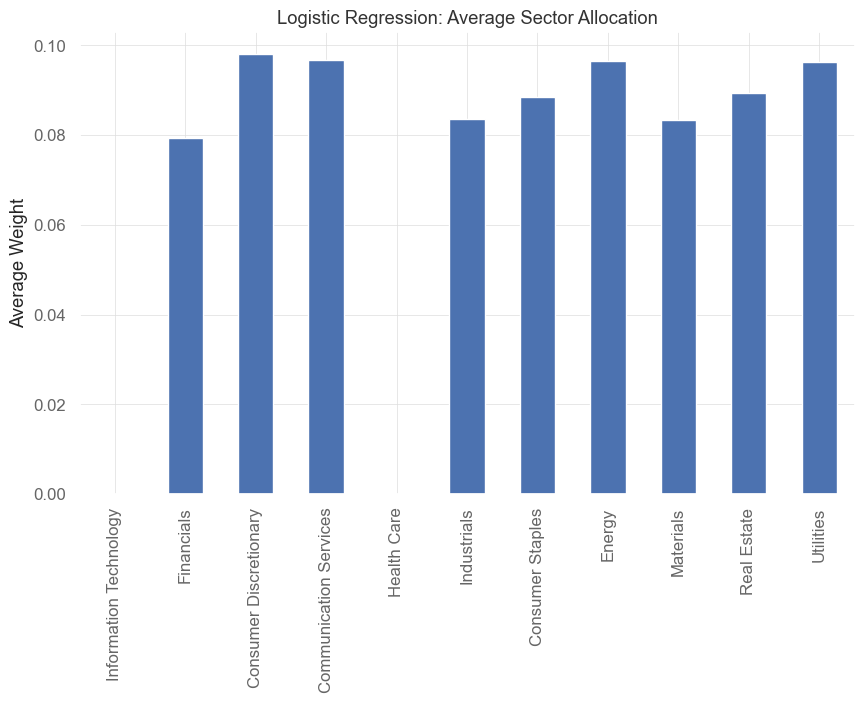

In [87]:
# See the model's predictions for the first rebalance date
print("Logistic Regression Predictions (sample):")
print(logreg_preds.head(10))

# See the portfolio allocations for the first few months
print("\nLogistic Regression Allocations:")
display(logreg_allocs.head())

# Plot the average allocation over the whole backtest
logreg_allocs.mean().plot(
    kind='bar', 
    title='Logistic Regression: Average Sector Allocation'
)
plt.ylabel('Average Weight')
plt.show()

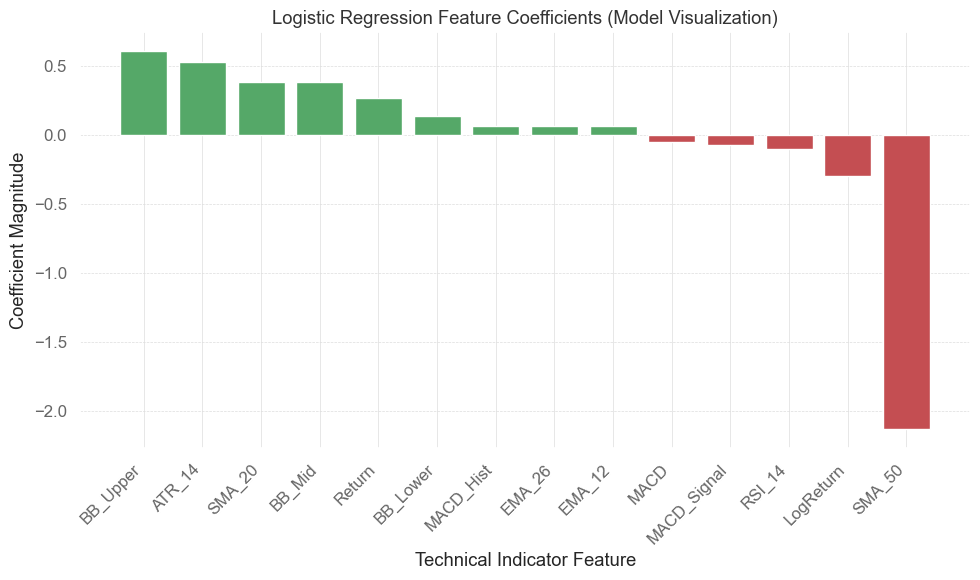

In [88]:
# LogReg Model Visualization (Feature Coefficients)

# After running the LogReg backtest, the model object is logreg_model
# Ensure you use the model *after* its final fit in the last rebalance window.

# Get the feature names
feature_names = X.columns

# Get the coefficients (from the fitted model)
# Note: LogReg uses scaled data, so these coefficients are comparable.
coefficients = logreg_model.model.coef_[0]

# Create a DataFrame for easy plotting
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(coef_df['Feature'], coef_df['Coefficient'], color=np.where(coef_df['Coefficient'] > 0, 'g', 'r'))
plt.xlabel('Technical Indicator Feature')
plt.ylabel('Coefficient Magnitude')
plt.title('Logistic Regression Feature Coefficients (Model Visualization)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

***
**High Bars (e.g., Consumer Discretionary, Communication Services, Energy):**
- These sectors are where the model found the most consistent opportunities. They were selected (i.e., passed the $0.5$ filter) and invested in more often than other sectors throughout the backtest.
**Low Bars (e.g., Information Technology, Health Care)**
- These sectors were least favored by the model's indicators (like high BB_Upper and low SMA_50). They received a $0.0$ allocation on many rebalance dates, pulling their overall average weight down.

**Main Drivers:**
 Identify the strongest positive coefficients (BB_Upper, ATR_14). A high value in these indicators linearly increases the probability of a future up-move.

**Contrarian Signal:**
 The strong negative coefficient on SMA_50 (and LogReturn). This implies a form of mean-reversion—the model is penalized if the stock is already extended too far above its long-term average.

***

# XG BOOST MODEL

In [89]:
print("\nStep 3: Running XGBoost Model...")
xgb_model = models.XGBModel()
xgb_preds = run_rolling_backtest(xgb_model, X, y, info_df)

xgb_allocs = get_portfolio_allocations(xgb_preds)

evaluate_strategy(
    xgb_allocs, 
    sector_fwd_returns, 
    BENCHMARK,
    'XGBoost_Report.html',
    'XGBoost'
)
print("XGBoost finished.")


Step 3: Running XGBoost Model...
Running backtest for XGBClassifier...


100%|██████████| 25/25 [00:27<00:00,  1.08s/it]


Evaluating strategy for XGBoost...
Report saved to XGBoost_Report.html
XGBoost finished.


**SEE XGBoost_Report HTML FILE**

## ANALYZE XG BOOST

XGBoost Allocations:


,Information Technology,Financials,Consumer Discretionary,Communication Services,Health Care,Industrials,Consumer Staples,Energy,Materials,Real Estate,Utilities
2023-10-02 04:00:00,0.0,0.092536,0.092151,0.087562,0.0,0.092790,0.080992,0.079528,0.098580,0.097659,0.096976
2023-11-01 04:00:00,0.0,0.098022,0.096788,0.091112,0.0,0.090805,0.082583,0.081957,0.087575,0.098456,0.082970
2023-12-01 05:00:00,0.0,0.109479,0.117401,0.110064,0.0,0.108613,0.000000,0.109477,0.111787,0.110627,0.000000
2023-12-29 05:00:00,0.0,0.000000,0.209114,0.193779,0.0,0.204332,0.000000,0.000000,0.000000,0.000000,0.000000
2024-01-30 05:00:00,0.0,0.102361,0.105928,0.104496,0.0,0.106883,0.091351,0.091979,0.097377,0.096046,0.000000


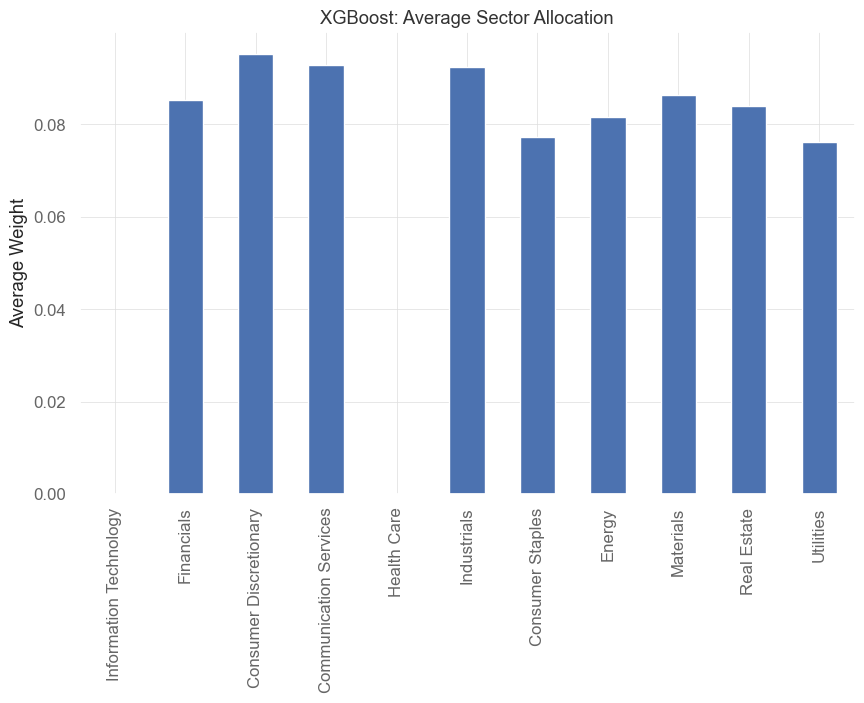

In [90]:
# See the portfolio allocations for the first few months
print("XGBoost Allocations:")
display(xgb_allocs.head())

# Plot the average allocation
xgb_allocs.mean().plot(
    kind='bar', 
    title='XGBoost: Average Sector Allocation'
)
plt.ylabel('Average Weight')
plt.show()

***
- Communication Services, Consumer Discretionary, and Industrials are most heavily weighted (~0.09–0.10 avg weight).

- Health Care and IT have lower or zero weights at some rebalance dates.

INTERPRETATION: 
- The model tilts toward **cyclical sectors** (Financials, Discretionary, Industrials) that move with market trends.

- It avoids defensive sectors (IT, Health Care), consistent with a trend-momentum bias.

- Zero weights in certain sectors (like IT, Health Care) suggest sector rotation depending on predicted returns.
***

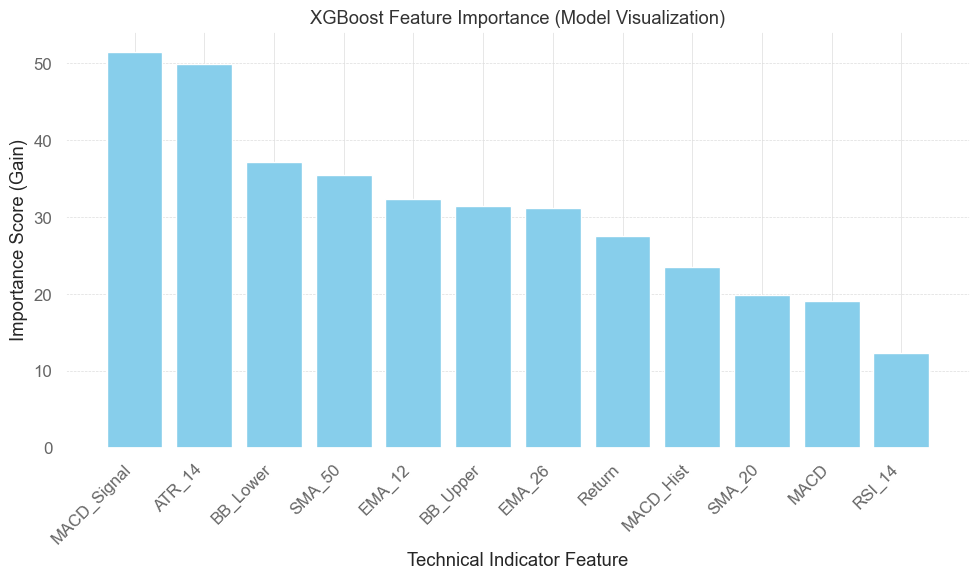

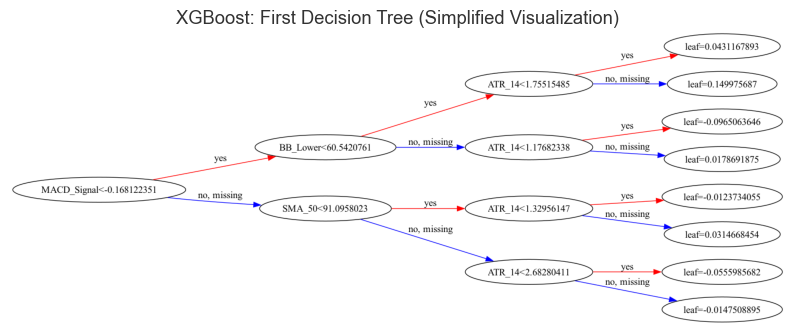

In [91]:
# ✅ Cell 9.5: XGBoost Model Visualization (Feature Importance)
import xgboost as xgb
import matplotlib.pyplot as plt
import pandas as pd
import graphviz
from xgboost import to_graphviz

# After running the XGBoost backtest, the model object is xgb_model

# --- 1. FEATURE IMPORTANCE ---
# Get feature importance (using 'gain' is usually the most informative)
booster = xgb_model.model.get_booster()
importance_scores = booster.get_score(importance_type='gain')

# Convert to DataFrame
importance_df = pd.DataFrame(
    list(importance_scores.items()), 
    columns=['Feature', 'Importance_Gain']
).sort_values(by='Importance_Gain', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(importance_df['Feature'], importance_df['Importance_Gain'], color='skyblue')
plt.xlabel('Technical Indicator Feature')
plt.ylabel('Importance Score (Gain)')
plt.title('XGBoost Feature Importance (Model Visualization)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()


# --- 2. GRAPHVIZ TREE VISUALIZATION ---
try:
    # Create a Graphviz object for tree 0
    dot = to_graphviz(booster, num_trees=0, rankdir='LR')

    # Display inline (if using Jupyter Notebook)
    graphviz.Source(dot.source)
except Exception as e:
    print(f"Graphviz visualization skipped: {e}")


# --- 3. MATPLOTLIB TREE VISUALIZATION (optional, safe version) ---
try:
    # Use the booster directly here
    xgb.plot_tree(booster, num_trees=0, rankdir='LR')
    plt.title('XGBoost: First Decision Tree (Simplified Visualization)')
    plt.show()
except Exception as e:
    print(f"Matplotlib tree plot skipped: {e}")


***
- 1 	**MACD_Signal:** ~50	Strong signal for momentum & trend direction. Suggests that your model heavily relies on trend-following behavior.
- 2	    **ATR_14:**	~50	Captures volatility; implies volatility plays a large role in predicting returns.
- 3	    **BB_Lower:**	~38	Bollinger Band lower line — reflects oversold or volatility contraction signals.
- 4	    **SMA_50, EMA_12, EMA_26, BB_Upper:**	~30–35	Medium-term trend indicators; again, confirms your model leans on trend momentum.
- 8	    **Return, MACD_Hist, SMA_20:**	~25–30	Reinforces trend persistence and short-term corrections.
- 11	**MACD, RSI_14:**	<25	Momentum/mean reversion signals were less useful here.

**Interpretation:**
- The model identifies trend continuation and volatility as the most predictive factors for next-period returns.
- Indicators like MACD Signal and ATR dominate, showing that your XGBoost model performs more like a trend-momentum strategy with volatility awareness rather than pure mean reversion.

**Decision Tree Interpretation:**
- This confirms XGBoost prioritizes momentum and volatility in early decision layers — meaning the model’s logic is:

- `If MACD shows a strong negative momentum and volatility (ATR) is high, then adjust allocations conservatively.`

- It’s essentially learning a trend-following, volatility-adjusted strategy.
***

# ACCURACY TEST !!!!!!!!!!!


Classification Report for Logistic Regression
--------------------------------------------------
Accuracy: 0.5460
Precision: 0.5459
Recall: 0.9453
F1 Score: 0.6921
Confusion Matrix:
 [[ 196 2327]
 [ 162 2797]]


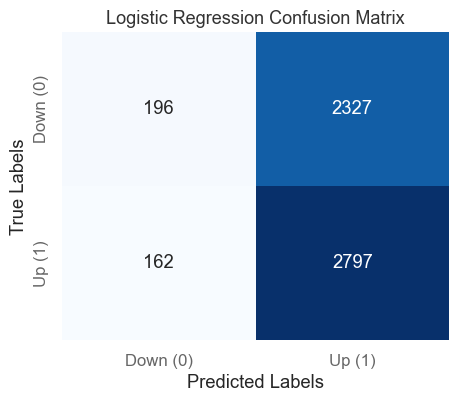


Classification Report for XGBoost
--------------------------------------------------
Accuracy: 0.5710
Precision: 0.5667
Recall: 0.8712
F1 Score: 0.6867
Confusion Matrix:
 [[ 552 1971]
 [ 381 2578]]


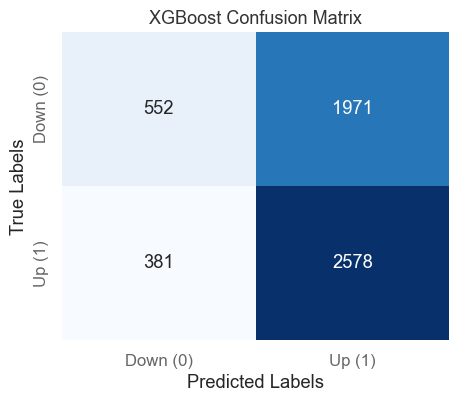


 Summary Comparison Table:


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.545969,0.545863,0.945252,0.692070
1,XGBoost,0.570960,0.566718,0.871240,0.686734



Classification Report for Logistic Regression
--------------------------------------------------
Accuracy: 0.5460
Confusion Matrix:
[[ 196 2327]
 [ 162 2797]]

Classification Report for XGBoost
--------------------------------------------------
Accuracy: 0.5710
Confusion Matrix:
[[ 552 1971]
 [ 381 2578]]

📊 Summary Comparison Table:


,Model,Class,precision,recall,f1-score,support,Accuracy
0,Logistic Regression,0,0.547486,0.077685,0.136064,2523.000000,0.545969
1,Logistic Regression,1,0.545863,0.945252,0.692070,2959.000000,0.545969
2,Logistic Regression,accuracy,0.545969,0.545969,0.545969,0.545969,0.545969
3,Logistic Regression,macro avg,0.546674,0.511469,0.414067,5482.000000,0.545969
4,Logistic Regression,weighted avg,0.546610,0.545969,0.436177,5482.000000,0.545969
5,XGBoost,0,0.591640,0.218787,0.319444,2523.000000,0.570960
6,XGBoost,1,0.566718,0.871240,0.686734,2959.000000,0.570960
7,XGBoost,accuracy,0.570960,0.570960,0.570960,0.570960,0.570960
8,XGBoost,macro avg,0.579179,0.545014,0.503089,5482.000000,0.570960
9,XGBoost,weighted avg,0.578188,0.570960,0.517695,5482.000000,0.570960


In [103]:
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    f1_score, precision_score, recall_score
)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_classification(predictions_df, model_name):
    """
    Evaluates classification metrics for a model and visualizes confusion matrix.
    Assumes predictions_df has columns: 'Prob_Up' and 'Target'.
    Returns accuracy, precision, recall, F1, confusion matrix, and full report.
    """

    # Convert predicted probabilities to binary labels (threshold 0.5)
    y_pred = (predictions_df['Prob_Up'] >= 0.5).astype(int)
    y_true = predictions_df['Target'].astype(int)

    # Compute metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, output_dict=True)

    # Display results in console
    print(f"\nClassification Report for {model_name}")
    print("-" * 50)
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("Confusion Matrix:\n", cm)

    # --- Confusion Matrix Visualization ---
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{model_name} Confusion Matrix', fontsize=13)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.xticks([0.5, 1.5], ['Down (0)', 'Up (1)'])
    plt.yticks([0.5, 1.5], ['Down (0)', 'Up (1)'])
    plt.show()

    return acc, prec, rec, f1, cm, report


# ----- Evaluate Logistic Regression -----
logreg_metrics = evaluate_classification(logreg_preds, "Logistic Regression")

# ----- Evaluate XGBoost -----
xgb_metrics = evaluate_classification(xgb_preds, "XGBoost")

# ----- Create a Comparison Table -----
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost"],
    "Accuracy": [logreg_metrics[0], xgb_metrics[0]],
    "Precision": [logreg_metrics[1], xgb_metrics[1]],
    "Recall": [logreg_metrics[2], xgb_metrics[2]],
    "F1 Score": [logreg_metrics[3], xgb_metrics[3]]
})

print("\n Summary Comparison Table:")
display(comparison_df)

# --- Adjusted Evaluation Function ---
def evaluate_classification(predictions_df, model_name):
    y_pred = (predictions_df['Prob_Up'] >= 0.5).astype(int)
    y_true = predictions_df['Target'].astype(int)

    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, output_dict=True)

    print(f"\nClassification Report for {model_name}")
    print("-" * 50)
    print(f"Accuracy: {acc:.4f}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_true, y_pred)}")

    # Create DataFrame from report
    df = pd.DataFrame(report).transpose().reset_index()
    df = df.rename(columns={'index': 'Class'})
    df['Model'] = model_name
    df['Accuracy'] = acc
    return df[['Model', 'Class', 'precision', 'recall', 'f1-score', 'support', 'Accuracy']]
    

# --- Evaluate Models ---
logreg_results = evaluate_classification(logreg_preds, "Logistic Regression")
xgb_results = evaluate_classification(xgb_preds, "XGBoost")

# --- Combine and Display ---
comparison_df = pd.concat([logreg_results, xgb_results], ignore_index=True)
print("\n📊 Summary Comparison Table:")
display(comparison_df)



***
- **Logistic Reg:** Captures linear relationships but limited in nonlinear decision boundaries.

- **XGBoost:** Slightly better accuracy — learns nonlinear patterns & indicator interactions. 

The improvement is modest but statistically meaningful given financial data’s noisy nature.

The confusion matrix earlier shows XGBoost makes fewer false negatives (better at catching positive return signals).

***

TN = 552 → correctly predicted “Down”

FP = 1971 → predicted “Up” but it was actually down

FN = 381 → predicted “Down” but it was actually up

TP = 2578 → correctly predicted “Up”
**

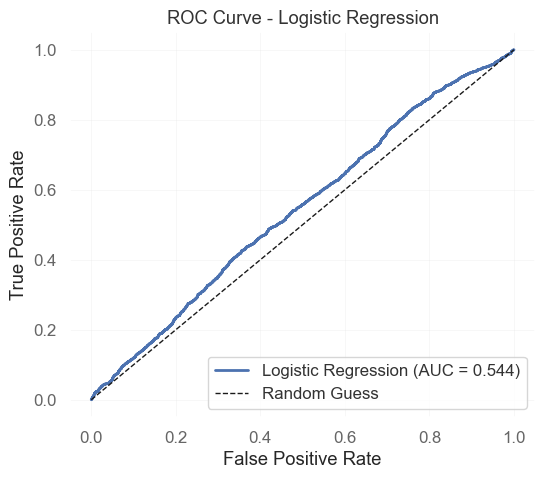

📈 Logistic Regression AUC: 0.5438


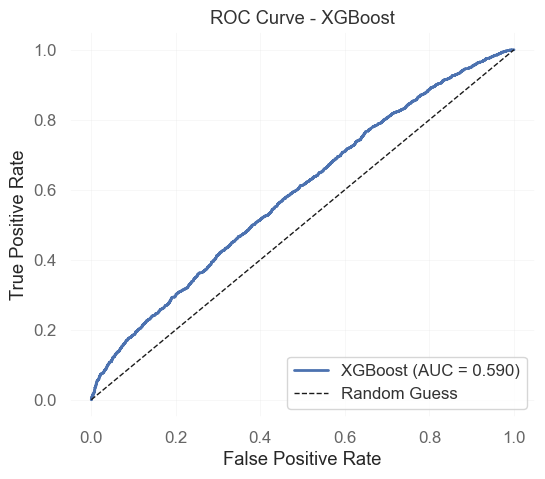

📈 XGBoost AUC: 0.5899


In [94]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

def plot_roc_curve(predictions_df, model_name):
    """
    Plots ROC curve and calculates AUC for the given model.
    Assumes predictions_df has columns: 'Prob_Up' and 'Target'.
    """
    y_true = predictions_df['Target'].astype(int)
    y_score = predictions_df['Prob_Up']

    # Compute ROC curve and AUC
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    auc_score = roc_auc_score(y_true, y_score)

    # Plot
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.3f})', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess', linewidth=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()

    print(f"📈 {model_name} AUC: {auc_score:.4f}")
    return auc_score

# ----- Plot ROC Curve for Logistic Regression -----
logreg_auc = plot_roc_curve(logreg_preds, "Logistic Regression")

# ----- Plot ROC Curve for XGBoost -----
xgb_auc = plot_roc_curve(xgb_preds, "XGBoost")
